# Wafer Anomaly Detection with PatchCore + EfficientNet-B1 (No Defect Tuning)

This notebook trains a PatchCore-style anomaly detector on normal wafers and selects the anomaly threshold without labeled defect tuning.

Evaluation uses a held-out test split with:
- normal wafers
- defect wafers

Pipeline:
1. Load and clean WM-811K style wafer data
2. Convert wafer maps to 3-channel tensors
3. Extract multi-scale patch embeddings from a pretrained CNN
4. Build PatchCore memory bank from train-normal patches
5. Score tune-normal and test images by nearest-neighbor patch distance
6. Select threshold from tune-normal percentile (unsupervised)
7. Evaluate with ROC-AUC, confusion matrix, and classification report

In [4]:
# Core imports
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Using device:', DEVICE)

Using device: cuda


In [5]:
# Configuration
DATA_PATH = '../../data/raw/LSWMD.pkl'
IMAGE_SIZE = 240
BATCH_SIZE = 128

TRAIN_NORMAL_N = 40_000
TUNE_NORMAL_N  =  5_000
# TUNE_DEFECT_N  =   5_000
TEST_NORMAL_N  =  5_000
TEST_DEFECT_N  =   250  

# PatchCore memory/scoring settings
MEMORY_BANK_MAX_PATCHES = 250000
SCORE_CHUNK = 1024
PATCHCORE_NN_K = 3
TOPK_PATCH_RATIO = 0.03
EFFNET_MID_FEATURE_IDX = 3
EFFNET_DEEP_FEATURE_IDX = 5
PATCH_EMBED_DIM = 128

# Unsupervised threshold setting (normal-only tuning)
THRESHOLD_PERCENTILE = 95.0

# Artifact output
ARTIFACT_DIR = '../../artifacts/x64/patchcore_efficientnet_b1_50k_no_defect_tuning'
MODEL_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'patchcore_efficientnet_b1_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(
    f'batch={BATCH_SIZE}, bank_max={MEMORY_BANK_MAX_PATCHES}, '
    f'chunk={SCORE_CHUNK}, amp={USE_CUDA}, topk_ratio={TOPK_PATCH_RATIO}, '
    f'nn_k={PATCHCORE_NN_K}, eff_mid={EFFNET_MID_FEATURE_IDX}, '
    f'eff_deep={EFFNET_DEEP_FEATURE_IDX}, emb_dim={PATCH_EMBED_DIM}'
)
print(f'Unsupervised threshold percentile: {THRESHOLD_PERCENTILE}')
print('Artifacts will be saved to:', ARTIFACT_DIR)

batch=128, bank_max=250000, chunk=1024, amp=True, topk_ratio=0.03, nn_k=3, eff_mid=3, eff_deep=5, emb_dim=128
Unsupervised threshold percentile: 95.0
Artifacts will be saved to: ../../artifacts/x64/patchcore_efficientnet_b1_50k_no_defect_tuning


In [6]:
# Load and clean labels
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled shape:', df.shape)
print('Normal wafers:', len(normal_df))
print('Defect wafers:', len(defect_df))

Raw shape: (811457, 6)
Labeled shape: (172950, 8)
Normal wafers: 147431
Defect wafers: 25519


In [7]:
# Enforce requested split sizes (no tune-defect split)
required_normals = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
required_defects = TEST_DEFECT_N

if len(normal_df) < required_normals:
    raise ValueError(f'Not enough normal wafers: need {required_normals}, found {len(normal_df)}')
if len(defect_df) < required_defects:
    raise ValueError(f'Not enough defect wafers: need {required_defects}, found {len(defect_df)}')

rng = np.random.default_rng(SEED)
normal_idx = rng.permutation(len(normal_df))
defect_idx = rng.permutation(len(defect_df))

normal_df_shuf = normal_df.iloc[normal_idx].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[defect_idx].reset_index(drop=True)

n0 = 0
n1 = TRAIN_NORMAL_N
n2 = TRAIN_NORMAL_N + TUNE_NORMAL_N
n3 = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N

train_normal_df = normal_df_shuf.iloc[n0:n1].copy()
tune_normal_df = normal_df_shuf.iloc[n1:n2].copy()
test_normal_df = normal_df_shuf.iloc[n2:n3].copy()

d0 = 0
d1 = TEST_DEFECT_N

test_defect_df = defect_df_shuf.iloc[d0:d1].copy()

print('Train normal:', len(train_normal_df))
print('Tune normal:', len(tune_normal_df))
print('Test normal:', len(test_normal_df))
print('Test defect:', len(test_defect_df))

Train normal: 40000
Tune normal: 5000
Test normal: 5000
Test defect: 250


In [8]:
# Wafer map -> 3ch tensor
def wafer_to_tensor(wafer_map, size=224):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=224):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

X_train, y_train = build_tensor(train_normal_df, IMAGE_SIZE)
X_tune_normal, y_tune_normal = build_tensor(tune_normal_df, IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df, IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df, IMAGE_SIZE)

print('X_train:', tuple(X_train.shape))
print('X_tune_normal:', tuple(X_tune_normal.shape))
print('X_test_normal:', tuple(X_test_normal.shape))
print('X_test_defect:', tuple(X_test_defect.shape))

X_train: (40000, 3, 240, 240)
X_tune_normal: (5000, 3, 240, 240)
X_test_normal: (5000, 3, 240, 240)
X_test_defect: (250, 3, 240, 240)


In [9]:
# DataLoaders
loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'shuffle': False,
}

train_loader = DataLoader(TensorDataset(X_train, y_train), **loader_kwargs)
tune_normal_loader = DataLoader(TensorDataset(X_tune_normal, y_tune_normal), **loader_kwargs)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kwargs)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kwargs)

print('Train batches:', len(train_loader))
print('Tune normal batches:', len(tune_normal_loader))
print('Test normal batches:', len(test_normal_loader))
print('Test defect batches:', len(test_defect_loader))

Train batches: 313
Tune normal batches: 40
Test normal batches: 40
Test defect batches: 2


In [10]:
# PatchCore feature extractor from pretrained EfficientNet-B1
class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        self.features = backbone.features
        self.mid_idx = EFFNET_MID_FEATURE_IDX
        self.deep_idx = EFFNET_DEEP_FEATURE_IDX
        self.project_dim = PATCH_EMBED_DIM
        with torch.inference_mode():
            dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            x = dummy
            f_mid = None
            f_deep = None
            for i, block in enumerate(self.features):
                x = block(x)
                if i == self.mid_idx:
                    f_mid = x
                if i == self.deep_idx:
                    f_deep = x
        if f_mid is None or f_deep is None:
            raise ValueError(f'Invalid EfficientNet feature indices: mid={self.mid_idx}, deep={self.deep_idx}')
        in_dim = f_mid.shape[1] + f_deep.shape[1]
        self.proj = nn.Linear(in_dim, self.project_dim, bias=False)

    def forward(self, x):
        f_mid = None
        f_deep = None
        for i, block in enumerate(self.features):
            x = block(x)
            if i == self.mid_idx:
                f_mid = x
            if i == self.deep_idx:
                f_deep = x
        if f_mid is None or f_deep is None:
            raise RuntimeError(f'Failed to collect EfficientNet feature maps at indices {self.mid_idx} and {self.deep_idx}.')
        return f_mid, f_deep

extractor = PatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

def patch_embeddings(xb):
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
            f2, f3 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb = torch.cat([f2, f3_up], dim=1)
            emb = emb.permute(0, 2, 3, 1).reshape(-1, emb.size(1))
            emb = extractor.proj(emb)
        emb = F.normalize(emb.float(), p=2, dim=1)
    return emb

In [11]:
# Build memory bank from train-normal patches ??keep tensors on GPU to avoid PCIe round-trips
sampled_patches = []
estimated_total_patches = None
total_seen_patches = 0
sample_ratio = 1.0

with torch.inference_mode():
    for xb, _ in train_loader:
        xb = xb.to(DEVICE)
        emb = patch_embeddings(xb)           # stays on GPU (no .cpu())
        total_seen_patches += len(emb)

        if estimated_total_patches is None:
            patches_per_image = len(emb) // len(xb)
            estimated_total_patches = patches_per_image * len(train_normal_df)
            sample_ratio = min(1.0, MEMORY_BANK_MAX_PATCHES / estimated_total_patches)
            print('Estimated raw memory bank patches:', estimated_total_patches)
            print('Sampling ratio:', round(sample_ratio, 6))

        if sample_ratio < 1.0:
            keep_n = max(1, int(round(len(emb) * sample_ratio)))
            keep_idx = torch.randperm(len(emb), device=DEVICE)[:keep_n]  # randperm on GPU
            emb = emb[keep_idx]

        sampled_patches.append(emb)          # GPU tensor

memory_bank = torch.cat(sampled_patches, dim=0)    # already on GPU
print('Sampled memory bank patches before trim:', len(memory_bank))
print('Observed raw patches during pass:', total_seen_patches)

if len(memory_bank) > MEMORY_BANK_MAX_PATCHES:
    keep_idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX_PATCHES]
    memory_bank = memory_bank[keep_idx]

memory_bank = F.normalize(memory_bank, p=2, dim=1).contiguous()   # no .to(DEVICE) needed
memory_bank_t = memory_bank.t().contiguous()
print('Final memory bank patches:', len(memory_bank), '| Emb dim:', memory_bank.shape[1])
print('Memory bank device:', memory_bank.device)

Estimated raw memory bank patches: 36000000
Sampling ratio: 0.006944
Sampled memory bank patches before trim: 250000
Observed raw patches during pass: 36000000
Final memory bank patches: 250000 | Emb dim: 128
Memory bank device: cuda:0


In [12]:
# PatchCore scoring with robust aggregation
# - Patch score: average distance to k nearest memory-bank neighbors
# - Image score: mean of top-k% most anomalous patch scores

def min_dist_to_bank(patches, bank_t, chunk=1024, nn_k=3):
    # Embeddings are L2-normalized, so Euclidean distance is derived from cosine similarity.
    mins = []
    for i in range(0, len(patches), chunk):
        p = patches[i:i + chunk]
        sim = p @ bank_t
        k = min(nn_k, sim.shape[1])
        best_sim = sim.topk(k=k, dim=1).values
        dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best_sim, min=0.0))
        mins.append(dist.mean(dim=1))
    return torch.cat(mins, dim=0)

def score_loader(loader, bank_t, topk_patch_ratio=0.02, nn_k=3):
    img_scores = []
    with torch.inference_mode():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
                f2, f3 = extractor(xb)
                f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
                emb = torch.cat([f2, f3_up], dim=1)
                emb = emb.permute(0, 2, 3, 1)
                b, h, w, c = emb.shape
                emb = emb.reshape(-1, c)
                emb = extractor.proj(emb)
            emb = F.normalize(emb.float(), p=2, dim=1)

            patch_scores = min_dist_to_bank(emb, bank_t, chunk=SCORE_CHUNK, nn_k=nn_k)
            patch_scores = patch_scores.reshape(b, h * w)
            topk_patches = max(1, int(round(patch_scores.shape[1] * topk_patch_ratio)))
            topk_patches = min(topk_patches, patch_scores.shape[1])
            score = patch_scores.topk(k=topk_patches, dim=1).values.mean(dim=1)
            img_scores.append(score.cpu())

    return torch.cat(img_scores).numpy()

train_scores = score_loader(
    train_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
tune_normal_scores = score_loader(
    tune_normal_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
test_normal_scores = score_loader(
    test_normal_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
test_defect_scores = score_loader(
    test_defect_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)

# Standardize scores using train-normal distribution for stable thresholding.
train_score_mu = float(np.mean(train_scores))
train_score_std = float(np.std(train_scores) + 1e-8)

train_scores_z = (train_scores - train_score_mu) / train_score_std
tune_normal_scores_z = (tune_normal_scores - train_score_mu) / train_score_std
test_normal_scores_z = (test_normal_scores - train_score_mu) / train_score_std
test_defect_scores_z = (test_defect_scores - train_score_mu) / train_score_std

# Save results for threshold tuning and final evaluation
np.savez_compressed(
    os.path.join(ARTIFACT_DIR, 'scores.npz'),
    train_scores_z=train_scores_z,
    tune_normal_scores_z=tune_normal_scores_z,
    test_normal_scores_z=test_normal_scores_z,
    test_defect_scores_z=test_defect_scores_z,
    train_score_mu=np.array(train_score_mu),
    train_score_std=np.array(train_score_std),
)

print(f'PatchCore scoring config -> nn_k={PATCHCORE_NN_K}, topk_patch_ratio={TOPK_PATCH_RATIO:.4f}')
print(f'Train normal score normalization -> mu={train_score_mu:.6f}, std={train_score_std:.6f}')

PatchCore scoring config -> nn_k=3, topk_patch_ratio=0.0300
Train normal score normalization -> mu=0.523583, std=0.033636


Selected z-threshold (unsupervised): 1.433622
Raw score threshold: 0.571805
Percentile used on tune-normal: 95.0


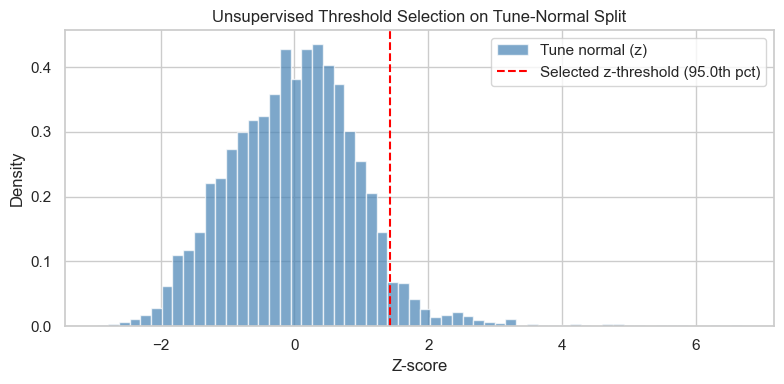

Run the next evaluation cell to report final test metrics with this threshold.


In [13]:
# Load saved results for threshold tuning and final evaluation
with np.load(os.path.join(ARTIFACT_DIR, 'scores.npz')) as data:
    train_scores_z = data['train_scores_z']
    tune_normal_scores_z = data['tune_normal_scores_z']
    test_normal_scores_z = data['test_normal_scores_z']
    test_defect_scores_z = data['test_defect_scores_z']
    train_score_mu = float(data['train_score_mu'])
    train_score_std = float(data['train_score_std'])

# Unsupervised threshold from tune-normal distribution only
threshold_z = float(np.percentile(tune_normal_scores_z, THRESHOLD_PERCENTILE))
threshold_raw = train_score_mu + threshold_z * train_score_std

print(f'Selected z-threshold (unsupervised): {threshold_z:.6f}')
print(f'Raw score threshold: {threshold_raw:.6f}')
print(f'Percentile used on tune-normal: {THRESHOLD_PERCENTILE}')

plt.figure(figsize=(8, 4))
plt.hist(tune_normal_scores_z, bins=60, alpha=0.7, color='steelblue', density=True, label='Tune normal (z)')
plt.axvline(threshold_z, color='red', linestyle='--', label=f'Selected z-threshold ({THRESHOLD_PERCENTILE}th pct)')
plt.xlabel('Z-score')
plt.ylabel('Density')
plt.title('Unsupervised Threshold Selection on Tune-Normal Split')
plt.legend()
plt.tight_layout()
plt.show()

print('Run the next evaluation cell to report final test metrics with this threshold.')

ROC-AUC (z-score): 0.9491
Applied z-threshold: 1.433622 | raw-threshold: 0.571805
              precision    recall  f1-score   support

      normal       0.99      0.95      0.97      5000
     anomaly       0.45      0.81      0.58       250

    accuracy                           0.94      5250
   macro avg       0.72      0.88      0.77      5250
weighted avg       0.96      0.94      0.95      5250



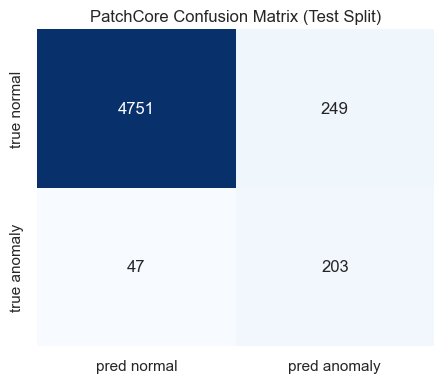

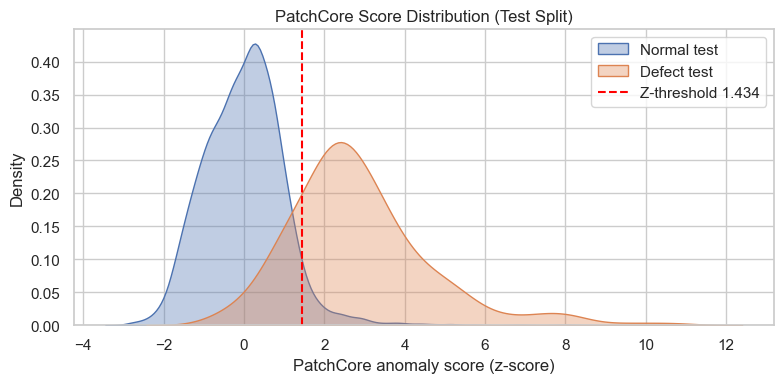

test defect samples: 250
Saved model artifact to: ../../artifacts/x64/patchcore_efficientnet_b1_50k_no_defect_tuning\patchcore_efficientnet_b1_model.pt
Saved metrics to: ../../artifacts/x64/patchcore_efficientnet_b1_50k_no_defect_tuning\evaluation_metrics.json


In [14]:
# threshold_z = 1.2
# Final evaluation on test split
y_true = np.concatenate([
    np.zeros(len(test_normal_scores_z), dtype=int),
    np.ones(len(test_defect_scores_z), dtype=int),
])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])
y_pred = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
report = classification_report(y_true, y_pred, target_names=['normal', 'anomaly'])

print(f'ROC-AUC (z-score): {roc_auc:.4f}')
print(f'Applied z-threshold: {threshold_z:.6f} | raw-threshold: {threshold_raw:.6f}')
print(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('PatchCore Confusion Matrix (Test Split)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(test_normal_scores_z, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_scores_z, label='Defect test', fill=True, alpha=0.35)
plt.axvline(threshold_z, color='red', linestyle='--', label=f'Z-threshold {threshold_z:.3f}')
plt.xlabel('PatchCore anomaly score (z-score)')
plt.ylabel('Density')
plt.title('PatchCore Score Distribution (Test Split)')
plt.legend()
plt.tight_layout()
plt.show()

print('test defect samples:', TEST_DEFECT_N)

# Store model artifacts
artifact = {
    'extractor_state_dict': extractor.state_dict(),
    'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std),
    'config': {
        'image_size': IMAGE_SIZE,
        'train_normal_n': TRAIN_NORMAL_N,
        'tune_normal_n': TUNE_NORMAL_N,
        'test_normal_n': TEST_NORMAL_N,
        'test_defect_n': TEST_DEFECT_N,
        'threshold_percentile': THRESHOLD_PERCENTILE,
        'threshold_method': 'unsupervised_percentile',
        'score_chunk': SCORE_CHUNK,
        'patchcore_nn_k': PATCHCORE_NN_K,
        'patchcore_topk_patch_ratio': TOPK_PATCH_RATIO,
        'effnet_mid_feature_idx': EFFNET_MID_FEATURE_IDX,
        'effnet_deep_feature_idx': EFFNET_DEEP_FEATURE_IDX,
        'patch_embed_dim': PATCH_EMBED_DIM,
    },
}
torch.save(artifact, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc_z': roc_auc,
    'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'threshold_percentile': THRESHOLD_PERCENTILE,
    'threshold_method': 'unsupervised_percentile',
    'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std),
    'confusion_matrix': cm.tolist(),
    'n_test_normal': int(len(test_normal_scores_z)),
    'n_test_defect': int(len(test_defect_scores_z)),
}
pd.Series(metrics).to_json(METRICS_EXPORT_PATH, indent=2)

print('Saved model artifact to:', MODEL_EXPORT_PATH)
print('Saved metrics to:', METRICS_EXPORT_PATH)

In [15]:
#print out each defected wafer's score and label for manual inspection
# Per-class breakdown
tmp = test_defect_df.copy()
tmp['score']    = test_defect_scores_z
tmp['detected'] = (test_defect_scores_z > threshold_z).astype(int)
print('\nPer-defect-class recall:')
display(tmp.groupby('failure_label').agg(
    count=('detected','count'), detected=('detected','sum'),
    recall=('detected','mean'), mean_score=('score','mean'),
).round(3).sort_values('recall'))
    


Per-defect-class recall:


,count,detected,recall,mean_score
failure_label,,,,
Scratch,11,6,0.545,1.885
Center,34,23,0.676,2.232
Edge-Loc,44,30,0.682,2.528
Loc,41,28,0.683,2.143
Edge-Ring,102,98,0.961,3.169
Donut,2,2,1.000,4.120
Near-full,3,3,1.000,6.108
Random,13,13,1.000,5.021


In [16]:
# Clear memory after run
vars_to_clear = [
    'train_dataset', 'test_normal_dataset', 'test_defect_dataset',
    'sample_x', 'sample_y',
    'sampled_patches', 'memory_bank', 'memory_bank_t',
    'train_scores', 'tune_normal_scores',
    'test_normal_scores', 'test_defect_scores',
    'train_scores_z', 'tune_normal_scores_z',
    'test_normal_scores_z', 'test_defect_scores_z',
    'scores', 'y_true', 'y_pred',
    'train_loader', 'tune_normal_loader',
    'test_normal_loader', 'test_defect_loader',
]
for name in vars_to_clear:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('Memory cleared (Python GC + CUDA cache).')

Memory cleared (Python GC + CUDA cache).


## Notes

- This variant uses no tune-defect split; thresholding is unsupervised via tune-normal percentile.
- Memory bank is capped by MEMORY_BANK_MAX_PATCHES to control RAM/VRAM.
- If GPU memory is tight, reduce BATCH_SIZE and/or SCORE_CHUNK.
- You can tune THRESHOLD_PERCENTILE for precision/recall tradeoff (e.g., 90, 95, 98).